## What are the most demanded skills for the top 3 most popular data roles?

### Methodology

1. Clean-up skill column
2. Calculate skill count based on job_title_short
3. Calculate skill percentage
4. Plot final findings

In [15]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset( 'lukebarousse/data_jobs')
df = dataset['train']. to_pandas ()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills']. apply( lambda x: ast. literal_eval(x) if pd.notna(x) else x)

In [6]:
df_US = df[df['job_location'] == 'United States']
df_skills = df_US.explode('job_skills')
df_skills[['job_title', 'job_skills']]
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = df_skills_count. reset_index(name='skill_count')
df_skills_count. sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count


,job_skills,job_title_short,skill_count
628,python,Data Scientist,3113
822,sql,Data Scientist,2164
655,r,Data Scientist,1882
870,tableau,Data Scientist,940
714,sas,Data Scientist,936
...,...,...,...
964,vue.js,Senior Data Engineer,1
965,watson,Data Engineer,1
968,webex,Data Engineer,1
969,webex,Data Scientist,1


In [7]:
job_titles = df_skills_count['job_title_short']. unique(). tolist()

job_titles = sorted(job_titles [:3] )

job_titles

['Data Engineer', 'Data Scientist', 'Senior Data Scientist']

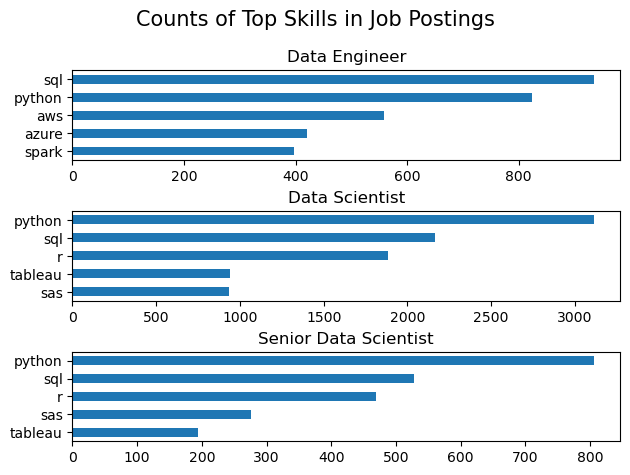

In [8]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count [df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax [i].set_ylabel('')
    ax [i].legend().set_visible(False)

fig. suptitle('Counts of Top Skills in Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5)
plt. show()

In [ ]:
df_job_title_count = df_US['job_title_short'] .value_counts().reset_index(name='jobs_total')

In [11]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')

df_skills_perc['skill_percent'] = 100 * df_skills_perc['skill_count'] / df_skills_perc['jobs_total']

df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Scientist,3113,4319,72.076870
1,sql,Data Scientist,2164,4319,50.104191
2,r,Data Scientist,1882,4319,43.574902
3,tableau,Data Scientist,940,4319,21.764297
4,sas,Data Scientist,936,4319,21.671683
...,...,...,...,...,...
987,vue.js,Senior Data Engineer,1,334,0.299401
988,watson,Data Engineer,1,1334,0.074963
989,webex,Data Engineer,1,1334,0.074963
990,webex,Data Scientist,1,4319,0.023154


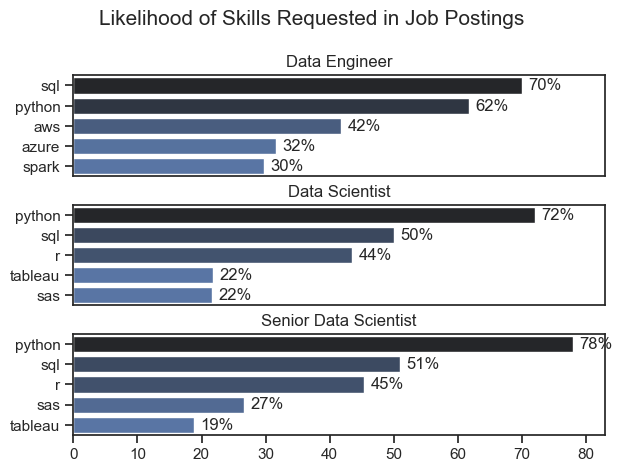

In [22]:
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style='ticks')


for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
   # df_plot.plot(kind='barh', x='job_skills', y='skill_percent', ax=ax[i], title=job_title)
    sns. barplot (data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0,83)

    for n, v in enumerate(df_plot['skill_percent']):
         ax[i]. text(v + 1, n, f'{v:.0f}%', va='center')

    if i != len(job_titles) - 1:
        ax[i] . set_xticks([])

fig. suptitle('Likelihood of Skills Requested in Job Postings', fontsize=15)
fig. tight_layout (h_pad=0.5) # fix the overlap
plt.show()